<a href="https://colab.research.google.com/github/dakyh/.NET-Multi-platform-App-UI-mainkh/blob/main/MylearnningVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Importation des librairies
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt



In [11]:
# 1. Installe la bibliothèque spécifique de l'UCI
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

# 2. Récupère le dataset "Student Performance" par son ID (320)
student_performance = fetch_ucirepo(id=320)

# 3. Récupère les données (X sont les caractéristiques, y est la note G3)
X = student_performance.data.features
y = student_performance.data.targets

# 4. Fusionne pour avoir un seul tableau propre
df = pd.concat([X, y], axis=1)

# 5. Affiche les premières lignes pour vérifier
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [12]:
# 3. Préprocessing : transformer Oui/Non en 0/1
binary_cols = ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})



In [13]:
# 4. Sélection des variables
features = ["studytime", "failures", "G1", "G2", "goout", "Dalc", "schoolsup", "absences"]
X = df[features]
y = df["G3"]



In [14]:
# 5. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [15]:
# 6. Modèle Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))



Random Forest RMSE: 1.2884531859164758


In [16]:
# 7. Modèle Deep Learning (Keras)
model = keras.Sequential([
    keras.layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1)  # sortie: note finale G3
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

y_pred_dl = model.predict(X_test).flatten()
print("Deep Learning RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dl)))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Deep Learning RMSE: 1.1612544657741453


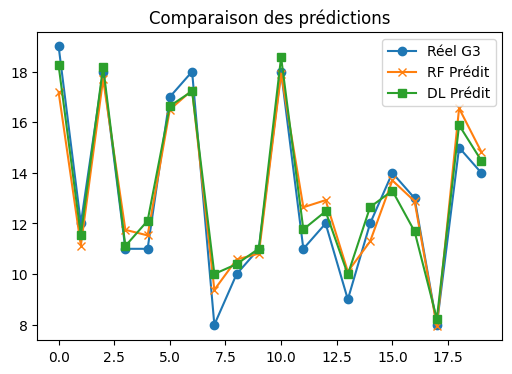

In [17]:
# 8. Exemple de visualisation
plt.figure(figsize=(6,4))
plt.plot(y_test.values[:20], label="Réel G3", marker="o")
plt.plot(y_pred_rf[:20], label="RF Prédit", marker="x")
plt.plot(y_pred_dl[:20], label="DL Prédit", marker="s")
plt.legend()
plt.title("Comparaison des prédictions")
plt.show()


In [22]:
!pip install streamlit
!streamlit run app.py
!git clone https://github.com/dakyh/MylearnningVision.git
!git add .
!git commit -m "Initial commit: Student Performance Project"
!git push origin main

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
fatal: destination path 'MylearnningVision' already exists and is not an empty directory.
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [21]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras

st.title("Prédiction de la performance des étudiants")

# Curseurs Streamlit
studytime = st.sidebar.slider("Temps d'étude", 1, 4, 2)
failures = st.sidebar.slider("Échecs passés", 0, 3, 0)
G1 = st.sidebar.slider("Note du 1er trimestre", 0, 20, 10)
G2 = st.sidebar.slider("Note du 2ème trimestre", 0, 20, 10)
goout = st.sidebar.slider("Sorties avec amis", 1, 5, 3)
Dalc = st.sidebar.slider("Alcool en semaine", 1, 5, 1)
schoolsup = st.sidebar.selectbox("Soutien scolaire", [0, 1])
absences = st.sidebar.slider("Absences", 0, 93, 5)

# Exemple de prédiction (ici juste une formule fictive)
X_input = np.array([[studytime, failures, G1, G2, goout, Dalc, schoolsup, absences]])

# TODO: charger tes modèles entraînés (Random Forest et Deep Learning)
# rf_pred = rf_model.predict(X_input)[0]
# dl_pred = dl_model.predict(X_input)[0]

# Pour l'instant, affichons une valeur fictive
st.write("Prédiction Random Forest : ", G2 + 2)
st.write("Prédiction Deep Learning : ", G2 + 1.5)

# Graphique progression
st.line_chart([G1, G2, G2+2])


2026-04-03 13:14:41.649 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 13:14:43.148 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-03 13:14:43.150 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 13:14:43.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 13:14:43.152 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 13:14:43.153 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 13:14:43.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 13:14:43.156 Thread 'MainThread': mi

DeltaGenerator()

In [34]:
import joblib

# Sauvegarde du Random Forest
rf_model_filename = "/content/MyLearningVision/rf_model.pkl"
joblib.dump(rf, rf_model_filename)

# Sauvegarde du modèle Deep Learning
dl_model_filename = "/content/MyLearningVision/dl_model.h5"
model.save(dl_model_filename)
